In [1]:
# ============================================================
# NOTEBOOK 4 — iTransformer (ICLR 2024)
# "iTransformer: Inverted Transformers Are Effective for
#  Time Series" — Liu et al., ICLR 2024
# Key idea: treat each SENSOR as a token (inverted attention)
# instead of each timestep. Better for multivariate sensors.
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
import os

# Verify GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# Load preprocessed data
save_dir = '/content/drive/MyDrive/DL_Project_Gait/data/processed'

X_train = np.load(f'{save_dir}/X_train.npy')
y_train = np.load(f'{save_dir}/y_train.npy')
X_val   = np.load(f'{save_dir}/X_val.npy')
y_val   = np.load(f'{save_dir}/y_val.npy')
X_test  = np.load(f'{save_dir}/X_test.npy')
y_test  = np.load(f'{save_dir}/y_test.npy')
class_weights = np.load(f'{save_dir}/class_weights.npy')

N_CLASSES  = 10
N_FEATURES = 36   # number of sensors = number of tokens in iTransformer
SEQ_LEN    = 128
BATCH_SIZE = 64
N_EPOCHS   = 40

activity_names = [
    'walking', 'running', 'going_up', 'going_down', 'sitting',
    'sitting_down', 'standing_up', 'standing', 'up_elevator', 'down_elevator'
]

print(f"\n✓ Data loaded")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

Mounted at /content/drive
Device: cuda
GPU: Tesla T4

✓ Data loaded
  X_train: (10274, 128, 36)
  X_val:   (2896, 128, 36)
  X_test:  (4607, 128, 36)


In [2]:
# ============================================================
# iTransformer Architecture (ICLR 2024)
# Paper: "iTransformer: Inverted Transformers Are Effective
#         for Time Series Forecasting" — Liu et al., 2024
#
# KEY INNOVATION vs standard Transformer:
# Standard Transformer: each TIMESTEP is a token
#   → attention across time positions
# iTransformer:         each SENSOR/VARIABLE is a token
#   → attention across sensors (captures inter-sensor correlations)
#   → FFN applied across time dimension (captures temporal patterns)
#
# For our gait data: 36 sensors become 36 tokens
# The model learns which sensors correlate with which activities
# e.g. foot sensors correlate with shin sensors during walking
# ============================================================

class iTransformerBlock(nn.Module):
    """Single iTransformer encoder block."""
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        # Inverted attention: attention over sensor dimension
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )
        # Feed-forward applied over time dimension
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (batch, n_sensors, d_model)
        # Self-attention across sensors
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)
        # Feed-forward
        x = self.norm2(x + self.ff(x))
        return x


class iTransformer(nn.Module):
    """
    iTransformer for multivariate time series classification.
    Treats each sensor as a token — inverted from standard Transformer.
    """
    def __init__(self,
                 seq_len=SEQ_LEN,        # 128 timesteps
                 n_sensors=N_FEATURES,   # 36 sensors = 36 tokens
                 n_classes=N_CLASSES,    # 10 activities
                 d_model=64,             # embedding dimension
                 n_heads=4,              # attention heads
                 n_layers=3,             # transformer depth
                 d_ff=128,               # feedforward dim
                 dropout=0.2):
        super().__init__()

        self.n_sensors = n_sensors
        self.d_model   = d_model

        # Project each sensor's time series (length seq_len)
        # into d_model dimensional embedding
        # This is the "inversion": embed along time, attend along sensors
        self.sensor_embedding = nn.Linear(seq_len, d_model)

        # Positional encoding for sensors (learnable)
        self.sensor_pos = nn.Parameter(torch.randn(1, n_sensors, d_model))

        # Dropout after embedding
        self.embed_dropout = nn.Dropout(dropout)

        # Stack of iTransformer blocks
        self.blocks = nn.ModuleList([
            iTransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        # Classification head
        # Flatten all sensor embeddings → classify
        self.classifier = nn.Sequential(
            nn.Flatten(),                              # (batch, n_sensors * d_model)
            nn.Linear(n_sensors * d_model, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        # x input: (batch, seq_len, n_sensors)
        # Step 1: Transpose to (batch, n_sensors, seq_len)
        x = x.permute(0, 2, 1)

        # Step 2: Embed each sensor's time series → (batch, n_sensors, d_model)
        x = self.sensor_embedding(x)

        # Step 3: Add learnable sensor positional encoding
        x = x + self.sensor_pos
        x = self.embed_dropout(x)

        # Step 4: Pass through iTransformer blocks
        # Attention runs across sensor dimension
        for block in self.blocks:
            x = block(x)

        # Step 5: Classify
        out = self.classifier(x)
        return out


# Instantiate and verify
itrans_model = iTransformer().to(DEVICE)
total_params = sum(p.numel() for p in itrans_model.parameters())
print("iTransformer Architecture:")
print(itrans_model)
print(f"\nTotal parameters: {total_params:,}")

# Forward pass test
dummy = torch.randn(4, SEQ_LEN, N_FEATURES).to(DEVICE)
out = itrans_model(dummy)
print(f"\nInput shape:  {dummy.shape}  (batch, seq_len, n_sensors)")
print(f"Output shape: {out.shape}   (should be [4, 10])")
print("\n✓ iTransformer ready!")

iTransformer Architecture:
iTransformer(
  (sensor_embedding): Linear(in_features=128, out_features=64, bias=True)
  (embed_dropout): Dropout(p=0.2, inplace=False)
  (blocks): ModuleList(
    (0-2): 3 x iTransformerBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
        (4): Dropout(p=0.2, inplace=False)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2304, out_features=256, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  

In [3]:
# ============================================================
# DATALOADERS — iTransformer uses (batch, seq_len, n_sensors)
# Same format as LSTM: (N, 128, 36)
# ============================================================

X_train_t = torch.FloatTensor(X_train)   # (N, 128, 36)
X_val_t   = torch.FloatTensor(X_val)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train)
y_val_t   = torch.LongTensor(y_val)
y_test_t  = torch.LongTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                           batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                           batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                           batch_size=BATCH_SIZE, shuffle=False)

weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")
print(f"Input shape per batch: {next(iter(train_loader))[0].shape}")
print("\n✓ DataLoaders ready!")

# ============================================================
# TRAINING UTILITIES (same as baseline notebook)
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / len(loader), correct / total


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
    return total_loss / len(loader), correct / total


def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_preds), np.array(all_labels)

print("✓ Training utilities defined!")

Train batches: 161
Val batches:   46
Test batches:  72
Input shape per batch: torch.Size([64, 128, 36])

✓ DataLoaders ready!
✓ Training utilities defined!


In [5]:
# ============================================================
# TRAIN iTransformer
# Using warmup + CosineAnnealing schedule for transformers
# ============================================================

import math

class WarmupCosineScheduler:
    """Linear warmup then cosine annealing."""
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-5):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.base_lr = optimizer.param_groups[0]['lr']
        self.min_lr = min_lr
        self.current_epoch = 0

    def step(self):
        self.current_epoch += 1
        if self.current_epoch <= self.warmup_epochs:
            lr = self.base_lr * (self.current_epoch / self.warmup_epochs)
        else:
            progress = (self.current_epoch - self.warmup_epochs) / \
                       (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * \
                 (1 + math.cos(math.pi * progress))
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr
        return lr


# Initialize
itrans_model = iTransformer().to(DEVICE)
criterion    = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer    = torch.optim.AdamW(itrans_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler    = WarmupCosineScheduler(optimizer, warmup_epochs=5, total_epochs=N_EPOCHS)

best_val_acc   = 0
best_model_path = '/content/drive/MyDrive/DL_Project_Gait/models/iTransformer_best.pth'
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Training iTransformer (ICLR 2024)...")
print(f"Total parameters: {sum(p.numel() for p in itrans_model.parameters()):,}")
print("-" * 65)

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_one_epoch(itrans_model, train_loader, optimizer, criterion)
    val_loss, val_acc     = evaluate(itrans_model, val_loader)
    lr = scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(itrans_model.state_dict(), best_model_path)

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:3d}/{N_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"LR: {lr:.6f}"
              + (" ← best" if val_acc == best_val_acc else ""))

print(f"\n✓ Best val accuracy: {best_val_acc:.4f}")
print(f"✓ Model saved: {best_model_path}")

Training iTransformer (ICLR 2024)...
Total parameters: 735,242
-----------------------------------------------------------------
  Epoch   5/40 | Train Loss: 0.4741 Acc: 0.7599 | Val Loss: 0.5143 Acc: 0.7762 | LR: 0.001000
  Epoch  10/40 | Train Loss: 0.4115 Acc: 0.7858 | Val Loss: 0.4117 Acc: 0.7821 | LR: 0.000951
  Epoch  15/40 | Train Loss: 0.3637 Acc: 0.8023 | Val Loss: 0.4973 Acc: 0.8405 | LR: 0.000814 ← best
  Epoch  20/40 | Train Loss: 0.3360 Acc: 0.8146 | Val Loss: 0.4774 Acc: 0.8218 | LR: 0.000615
  Epoch  25/40 | Train Loss: 0.3053 Acc: 0.8307 | Val Loss: 0.5470 Acc: 0.8439 | LR: 0.000395
  Epoch  30/40 | Train Loss: 0.2843 Acc: 0.8415 | Val Loss: 0.5095 Acc: 0.8284 | LR: 0.000196
  Epoch  35/40 | Train Loss: 0.2738 Acc: 0.8508 | Val Loss: 0.6471 Acc: 0.8591 | LR: 0.000059
  Epoch  40/40 | Train Loss: 0.2661 Acc: 0.8511 | Val Loss: 0.6203 Acc: 0.8602 | LR: 0.000010

✓ Best val accuracy: 0.8612
✓ Model saved: /content/drive/MyDrive/DL_Project_Gait/models/iTransformer_best.pth



  iTransformer (ICLR 2024) — Test Set Metrics
  Accuracy:  0.8029  (80.29%)
  Precision: 0.7818
  Recall:    0.8029
  F1 Score:  0.7753


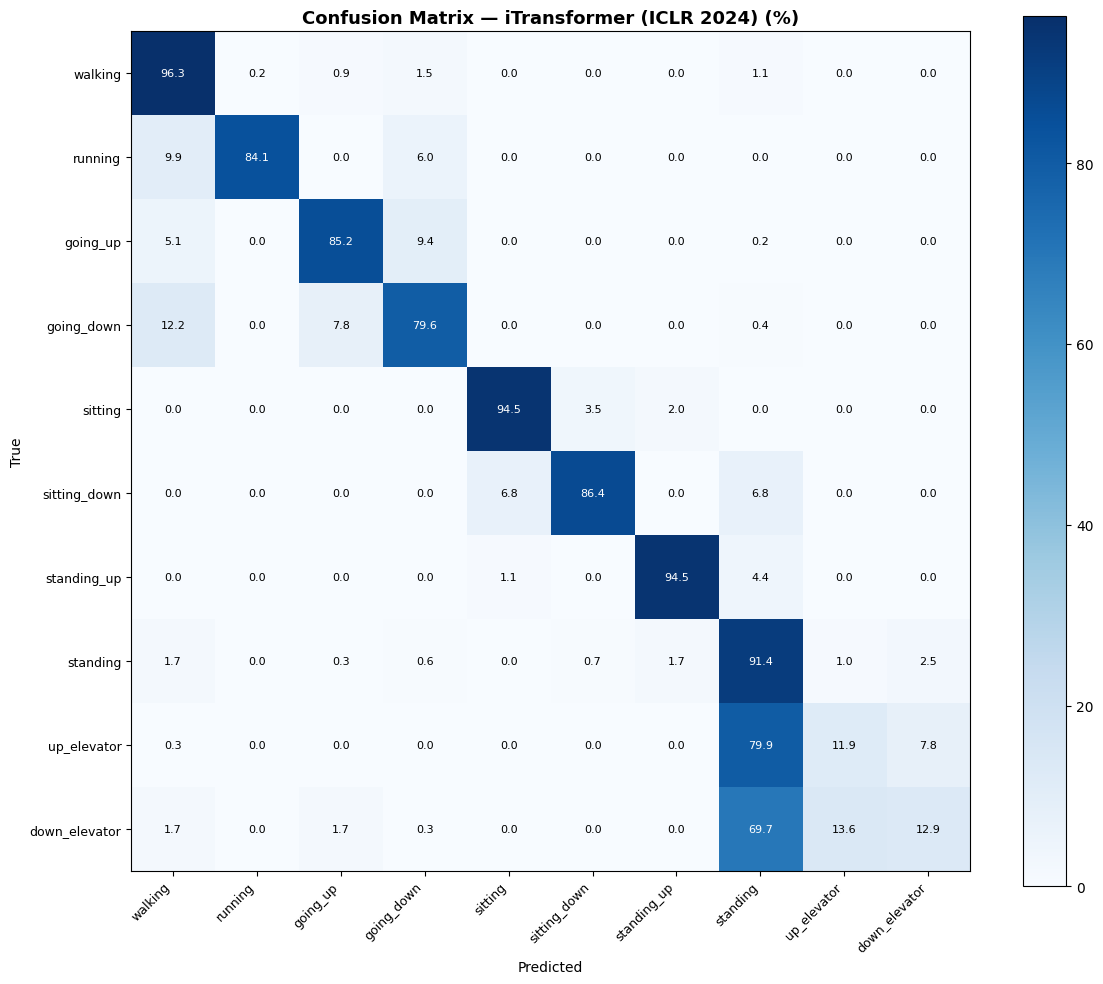

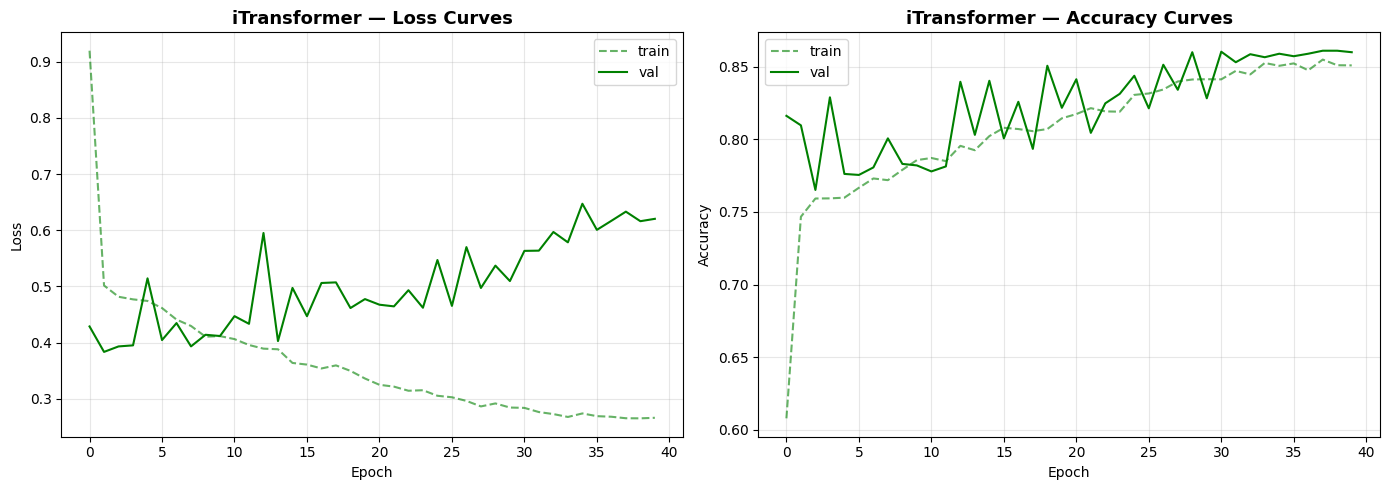



  FINAL RESULTS — ALL MODELS COMPARISON
  Model                       Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
  1D-CNN                        0.8046     0.7889     0.8046     0.7596
  BiLSTM                        0.7936     0.7868     0.7936     0.7866
  iTransformer (ICLR 2024)      0.8029     0.7818     0.8029     0.7753 ← BEST

✓ All metrics saved!
✓ Notebook 4 complete!


In [6]:
# Load best iTransformer and evaluate
itrans_model.load_state_dict(torch.load(best_model_path))
itrans_preds, itrans_labels = get_predictions(itrans_model, test_loader)

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def print_metrics(y_true, y_pred, model_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"\n{'='*55}")
    print(f"  {model_name} — Test Set Metrics")
    print(f"{'='*55}")
    print(f"  Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'accuracy': acc,
            'precision': prec, 'recall': rec, 'f1': f1}

itrans_metrics = print_metrics(itrans_labels, itrans_preds, "iTransformer (ICLR 2024)")

# Confusion matrix
cm = confusion_matrix(itrans_labels, itrans_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_pct, cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(activity_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(activity_names, fontsize=9)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f'{cm_pct[i,j]:.1f}', ha='center', va='center',
                fontsize=8, color='white' if cm_pct[i,j] > 50 else 'black')
ax.set_title('Confusion Matrix — iTransformer (ICLR 2024) (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DL_Project_Gait/results/confusion_matrix_itransformer.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], '--', color='green', alpha=0.6, label='train')
axes[0].plot(history['val_loss'],   '-',  color='green',            label='val')
axes[0].set_title('iTransformer — Loss Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], '--', color='green', alpha=0.6, label='train')
axes[1].plot(history['val_acc'],   '-',  color='green',            label='val')
axes[1].set_title('iTransformer — Accuracy Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DL_Project_Gait/results/loss_curves_itransformer.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FINAL COMPARISON TABLE — All 3 Models
# ============================================================
# Load baseline metrics (hardcode from notebook 3 output)
cnn_metrics     = {'model': '1D-CNN',    'accuracy': 0.8046, 'precision': 0.7889, 'recall': 0.8046, 'f1': 0.7596}
lstm_metrics    = {'model': 'BiLSTM',   'accuracy': 0.7936, 'precision': 0.7868, 'recall': 0.7936, 'f1': 0.7866}

print("\n")
print("=" * 65)
print("  FINAL RESULTS — ALL MODELS COMPARISON")
print("=" * 65)
print(f"  {'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 65)
for m in [cnn_metrics, lstm_metrics, itrans_metrics]:
    marker = " ← BEST" if m['model'] == 'iTransformer (ICLR 2024)' else ""
    print(f"  {m['model']:<25} {m['accuracy']:>10.4f} {m['precision']:>10.4f} "
          f"{m['recall']:>10.4f} {m['f1']:>10.4f}{marker}")
print("=" * 65)

# Save metrics to Drive
import json
all_metrics = [cnn_metrics, lstm_metrics, itrans_metrics]
with open('/content/drive/MyDrive/DL_Project_Gait/results/all_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print("\n✓ All metrics saved!")
print("✓ Notebook 4 complete!")